In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [3]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2010-2021_filled.csv', encoding=enc)


In [4]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-01,2010,1,2009-12-07,39.662866,22.635299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.662866,22.635299,14407.0,14025.0,39.662866,22.635299,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,2010-01-01,39.650181,22.650104,0.000441,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000441,0.000441
1,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-16,2010,1,2009-12-07,39.662866,22.635299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,39.662866,22.635299,14295.0,13485.0,39.662866,22.635299,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,2010-01-16,39.650181,22.650104,18.932700,2010-01-09,2010-01-02,2010-01-09,2010-01-02,13.140626,18.916778
2,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-01,2010,1,2009-12-07,39.752697,22.707165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.752697,22.707165,14367.0,NaN,39.752697,22.707165,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,2010-01-01,39.750182,22.750104,0.030362,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.030362,0.030362
3,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-16,2010,1,2009-12-07,39.752697,22.707165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,39.752697,22.707165,14093.0,13628.0,39.752697,22.707165,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,2010-01-16,39.750182,22.750104,50.056047,2010-01-09,2010-01-02,2010-01-09,2010-01-02,33.498169,49.542448
4,αγιας,θεσσαλιας,22.73031,39.79054,2010-01-01,2010,1,2009-12-07,39.788630,22.729622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,39.788630,22.729622,14227.0,NaN,39.788630,22.729622,13896.166667,13803.75,13802.111111,13714.000000,14134.000000,13810.285714,14421.769231,13843.333333,2010-01-01,39.750182,22.750104,0.030362,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.030362,0.030362


In [5]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [6]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [7]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [8]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14407.0,14025.0,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,0.000441,0.000441,0.000441
1,αγιας,θεσσαλιας,22.63715,39.66477,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14295.0,13485.0,14216.714286,13830.00,14246.000000,13866.538462,14623.071429,13950.611111,14915.764706,14069.857143,18.932700,13.140626,18.916778
2,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14367.0,NaN,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,0.030362,0.030362,0.030362
3,αγιας,θεσσαλιας,22.70702,39.75460,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14093.0,13628.0,14225.500000,13773.40,13996.500000,13740.222222,14417.615385,13833.750000,14555.555556,13875.785714,50.056047,33.498169,49.542448
4,αγιας,θεσσαλιας,22.73031,39.79054,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14227.0,NaN,13896.166667,13803.75,13802.111111,13714.000000,14134.000000,13810.285714,14421.769231,13843.333333,0.030362,0.030362,0.030362


In [9]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2010-01-01,αγιας,θεσσαλιας,22.750267,39.710970,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.714286,14043.0,14144.784184,13859.708503,14085.070635,13813.365812,14450.201092,13902.285681,14604.807569,13996.636316,0.018327,0.018327,0.018327
1,2010-01-01,αλμυρου,θεσσαλιας,22.692366,39.136391,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14511.777778,14227.0,14186.415300,13889.104417,14237.209041,13872.420226,14562.648962,13970.509532,14710.665664,14064.744390,0.210382,0.210382,0.210382
2,2010-01-01,αλοννησου,θεσσαλιας,24.073790,39.328960,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14548.000000,14276.0,14251.272727,14165.875000,14178.833333,14059.285714,14412.266667,14153.944444,14600.080000,14184.529412,0.000000,0.000000,0.000000
3,2010-01-01,αργιθεας,θεσσαλιας,21.430513,39.221380,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13671.244444,13673.444444,13853.958333,13610.345238,14256.170635,13799.499573,14494.970238,13979.482143,49.209201,49.209201,49.209201
4,2010-01-01,βολου,θεσσαλιας,22.883800,39.351977,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14576.666667,NaN,14359.732143,13897.046296,14340.338384,13871.508929,14628.190476,13984.622938,14876.861477,14096.591800,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,2021-12-16,τεμπων,θεσσαλιας,22.553160,39.852112,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13933.387063,13681.367460,14200.925735,13893.654484,14283.901681,13796.241007,14616.180112,13932.598700,1202.290178,58.108282,87.904479
7196,2021-12-16,τρικκαιων,θεσσαλιας,21.797560,39.635058,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14140.314423,13697.631349,14358.253773,13912.150104,14537.978095,13803.803680,14827.634685,14005.430544,1617.381678,66.377516,128.112311
7197,2021-12-16,τυρναβου,θεσσαλιας,22.343000,39.828472,2021.0,12.0,0.410104,0.187286,-0.272235,-0.187286,0.393206,0.184501,-0.26368,-0.184501,0.029704,0.058359,0.030164,0.058359,NaN,NaN,14036.815476,13722.609091,14303.707292,13897.720588,14491.201157,13824.337912,14753.932767,13972.226103,1244.257719,48.910871,86.194025
7198,2021-12-16,φαρκαδονας,θεσσαλιας,22.020557,39.603750,2021.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14163.080342,13727.400000,14363.222278,13913.152256,14569.512821,13860.088889,14810.315873,14057.720044,1441.876840,55.608775,115.182489


In [10]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [11]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [12]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [13]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [14]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [15]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'THESSALY'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [16]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [17]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


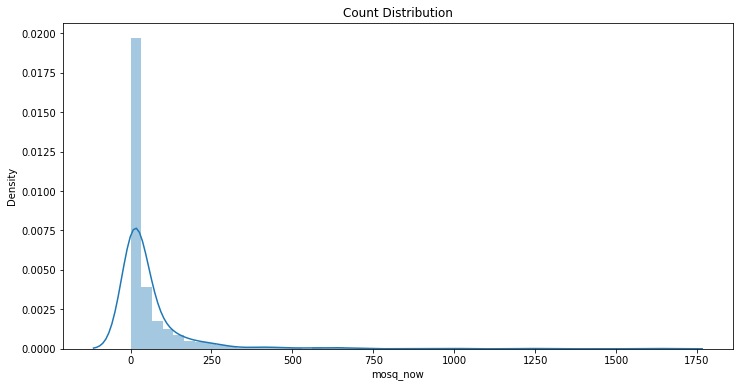

In [18]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [19]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

C:\Users\dimit\AppData\Local\Temp/ipykernel_2784/187358562.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


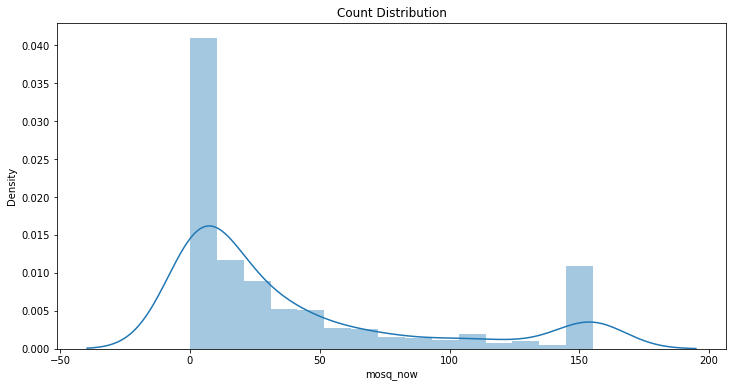

In [20]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

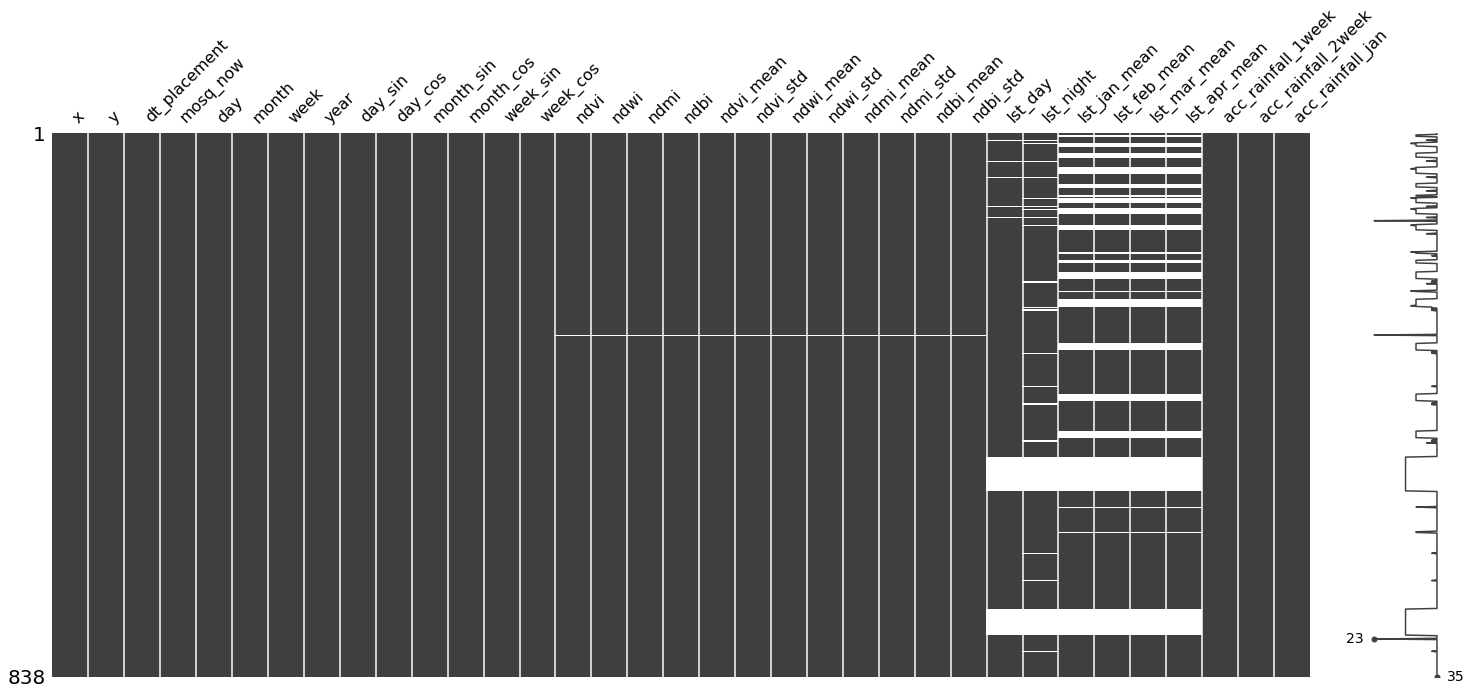

In [21]:
missingno.matrix(mosquito_data_nuts2)

In [22]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [23]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

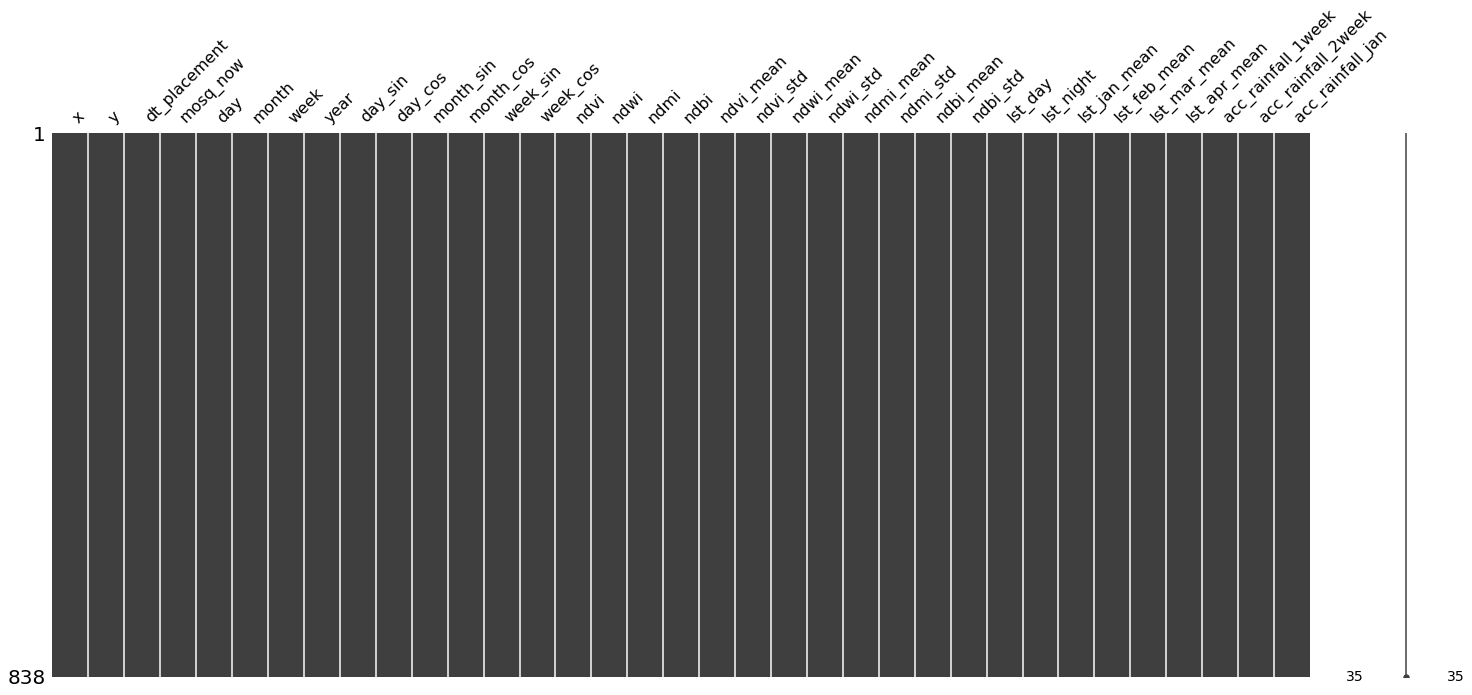

In [24]:
missingno.matrix(mosquito_data_nuts2)

In [25]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [26]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   16.5 155.3]


f:\My Drive\NOA\MBD-Prediction\Greece\notebooks\Thessaly\../../../Mamoth Modules\Initializer_Module.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1.loc[:,'mosq_bins(t+1)'] =  culex
f:\My Drive\NOA\MBD-Prediction\Greece\notebooks\Thessaly\../../../Mamoth Modules\Initializer_Module.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1.loc[:,'mosq_bins(t+1)'] =  culex
f:\My Drive\NOA\MBD-Prediction\Greece\notebooks\Thessaly\../../../Mamoth Modules\Initializer_Module.py:151: SettingWithCopyWar

In [27]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 41.89980 | Val Loss: 32.63457 | Train Acc: 4.471| Val Acc: 4.113
Epoch 002: | Train Loss: 37.74914 | Val Loss: 31.42315 | Train Acc: 3.699| Val Acc: 3.884
Epoch 003: | Train Loss: 35.58188 | Val Loss: 28.73279 | Train Acc: 3.209| Val Acc: 3.395
Epoch 004: | Train Loss: 34.94710 | Val Loss: 27.00916 | Train Acc: 3.053| Val Acc: 3.178
Epoch 005: | Train Loss: 34.19113 | Val Loss: 25.06868 | Train Acc: 2.956| Val Acc: 2.572
Epoch 006: | Train Loss: 33.56696 | Val Loss: 23.91486 | Train Acc: 2.831| Val Acc: 2.117
Epoch 007: | Train Loss: 33.12950 | Val Loss: 23.52990 | Train Acc: 2.724| Val Acc: 2.051
Epoch 008: | Train Loss: 33.10318 | Val Loss: 23.35828 | Train Acc: 2.721| Val Acc: 2.033
Epoch 009: | Train Loss: 32.70038 | Val Loss: 23.51753 | Train Acc: 2.691| Val Acc: 1.793
Epoch 010: | Train Loss: 32.79870 | Val Loss: 23.66243 | Train Acc: 2.688| Val Acc: 1.983
Epoch 011: | Train Loss: 32.66436 | Val Loss: 23.68801 | Train Acc: 2.578| Val Acc: 1.975
Epoch 012:

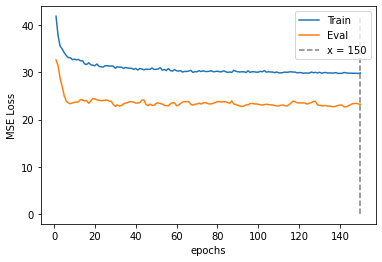

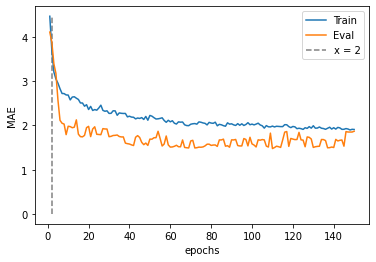

In [28]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [29]:
metrics(train, test, threshold=30)

MAE on train set:  21.78281401945023
min prediction: 1
max prediction: 199

MAE on test set:  26.19160325951064
Error ⩽ 30: 67.94 %
min prediction: 1
max prediction: 217


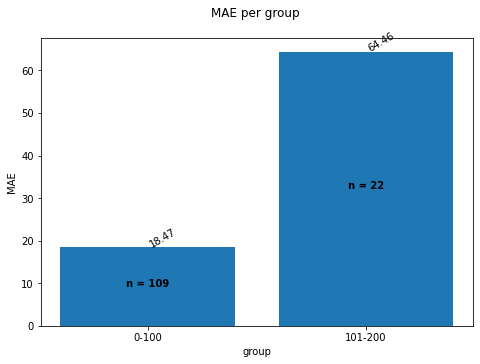

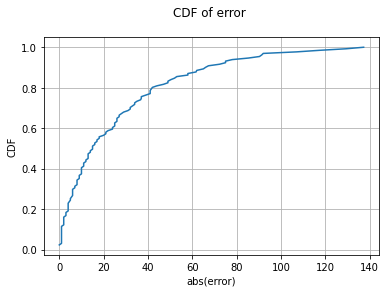

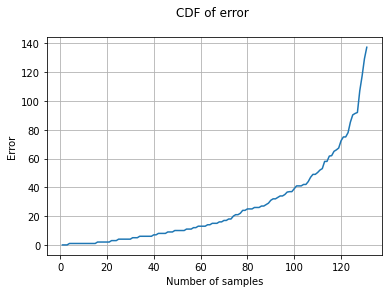

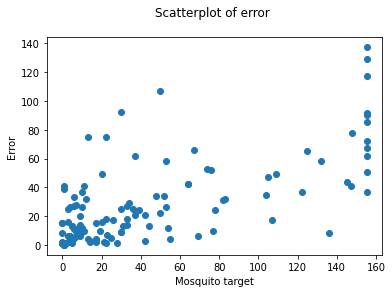

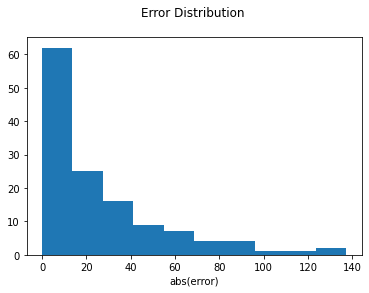

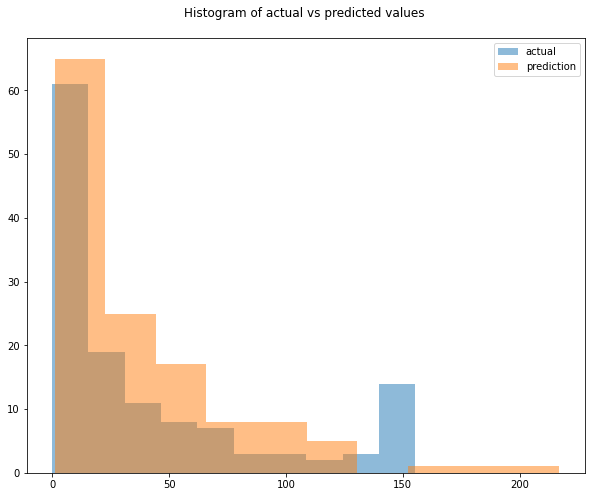

In [30]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 33.69533 | Val Loss: 0.04083 | Train Acc: 2.394| Val Acc: 0.045
Epoch 002: | Train Loss: 33.65913 | Val Loss: 0.27290 | Train Acc: 2.299| Val Acc: 0.955
Epoch 003: | Train Loss: 32.83641 | Val Loss: 0.39584 | Train Acc: 2.248| Val Acc: 0.955
Epoch 004: | Train Loss: 32.88412 | Val Loss: 0.55826 | Train Acc: 2.231| Val Acc: 0.955
Epoch 005: | Train Loss: 32.42400 | Val Loss: 0.49009 | Train Acc: 2.173| Val Acc: 0.955
Epoch 006: | Train Loss: 32.38362 | Val Loss: 0.40713 | Train Acc: 2.142| Val Acc: 0.955
Epoch 007: | Train Loss: 32.72633 | Val Loss: 0.60927 | Train Acc: 2.131| Val Acc: 0.955
Epoch 008: | Train Loss: 32.42200 | Val Loss: 0.39838 | Train Acc: 2.157| Val Acc: 0.955
Epoch 009: | Train Loss: 32.45853 | Val Loss: 0.14756 | Train Acc: 2.139| Val Acc: 0.045
Epoch 010: | Train Loss: 32.25569 | Val Loss: 0.09049 | Train Acc: 2.116| Val Acc: 0.045
Epoch 011: | Train Loss: 32.35217 | Val Loss: 0.10507 | Train Acc: 2.117| Val Acc: 0.045
Epoch 012: | Train Lo

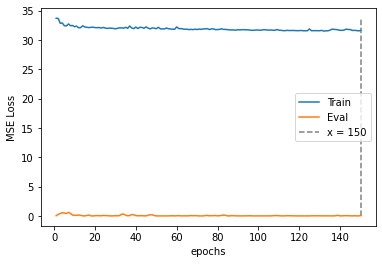

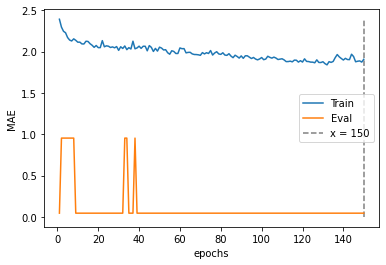

In [31]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [32]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [33]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [34]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [35]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [36]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [37]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

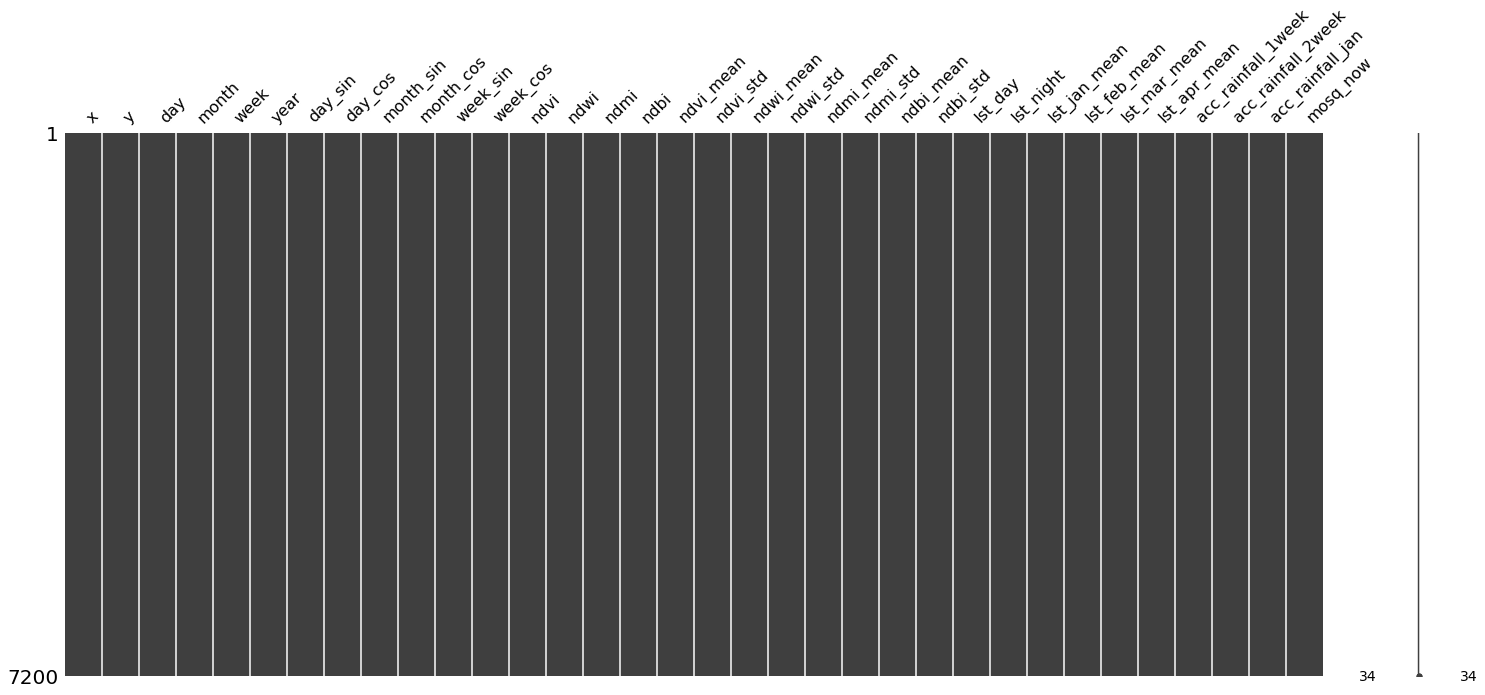

In [38]:
missingno.matrix(dataset_mamoth)

In [39]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [40]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [41]:
predictions = give_predictions(model, dataset_mamoth)

In [42]:
mosqutio_predictions['mosq_pred'] = predictions

In [43]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.750267,39.710970,2010-01-01,8
1,22.692366,39.136391,2010-01-01,1
2,24.073790,39.328960,2010-01-01,1
3,21.430513,39.221380,2010-01-01,12
4,22.883800,39.351977,2010-01-01,1
...,...,...,...,...
7195,22.553160,39.852112,2021-12-16,59
7196,21.797560,39.635058,2021-12-16,36
7197,22.343000,39.828472,2021-12-16,12
7198,22.020557,39.603750,2021-12-16,49


In [44]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2021.csv', index = False)